## Project 1

The goal of the first project is to do some wrangling, EDA, and visualization, and generate sequences of values. We will focus on:

- CDC National Health and Nutritional Examination Survey (NHANES, 1999-2000): https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/default.aspx?BeginYear=1999
- CDC Linked Mortality File (LMF, 1999-2000): https://www.cdc.gov/nchs/data-linkage/mortality-public.htm

NHANES is a rich panel dataset on health and behavior, collected bi-yearly from around 1999 to now. We will focus on the 1999 wave, because that has the largest follow-up window, providing us with the richest mortality data. The mortality data is provided by the CDC Linked Mortality File.

The purpose of the project is to use $k$-NN to predict who dies (hard or soft classification) and how long they live (regression).



### Part 1: Wrangling and EDA (40/100 pts)

First, go to the NHANES and LMF web sites and familiarize yourself with the data sources. Download codebooks. Think about what resources are available. The CDC Linked Mortality File is somewhat of a pain to work with, so I have pre-cleaned it for you. It is available at httts://github.com/ds4e/undergraduate_ml_assignments in the data folder, as `lmf_parsed.cav`. From the CDC LMF web page, get the SAS program to load the data; it is the real codebook.

Second, download the demographic data for the 1999--2000 wave from the NHANES page. You can use the following code chunk to merge the LMF and DEMO data:

``` python
import pandas as pd
mdf = pd.read_csv('linked_mortality_file_1999_2000.csv') # Load mortality file
print( mdf.head() )
gdf = pd.read_sas("DEMO.xpt", format="xport") # Load demographics file
print( gdf.head() )
df = gdf.merge(mdf, on="SEQN", how="inner") # Merge mortality and demographics on SEQN variable
```

Third, the variables `ELIGSTAT`, `MORTSTAT`, `PERMTH_INT`, and `RIDAGEEX` are particularly important. Look them up in the documentation and clearly describe them. (5/100 pts.)

Second, the goal of the project is to use whatever demographic, behavioral, and health data you like to predict mortality (`MORTSTAT`) and life expectancy (`PERMTH_INT`). Go to the NHANES 1999--2000 web page and select your data and download it. Clearly explain your rationale for selecting these data. Use `.merge` to combine your data into one complete dataframe. Document missing values. (5/100 pts)

Third, do basic EDA and visualization of the key variables. Are any important variables skewed? Are there outliers? How correlated are pairs of variables? Do pairs of categorical variables exhibit interesting patterns in contingency tables? Provide a clear discussion and examination of the data and the variables you are interested in using. (20/100 pts)



In [1]:
!git clone https://github.com/nathan4luu/DS-3001-Project-1.git


Cloning into 'DS-3001-Project-1'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 38 (delta 8), reused 12 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (38/38), 10.20 MiB | 6.48 MiB/s, done.
Resolving deltas: 100% (8/8), done.


In [2]:
import pandas as pd

mdf = pd.read_csv('/content/DS-3001-Project-1/linked_mortality_file_1999_2000.csv') # Load mortality file
print( mdf.head() )
gdf = pd.read_sas('/content/DS-3001-Project-1/DEMO.xpt', format="xport") # Load demographics file
print( gdf.head() )
df = gdf.merge(mdf, on="SEQN", how="inner") # Merge mortality and demographics on SEQN variable



   SEQN  ELIGSTAT  MORTSTAT  UCOD_LEADING  DIABETES  HYPERTEN  PERMTH_INT  \
0     1         2       NaN           NaN       NaN       NaN         NaN   
1     2         1       1.0           6.0       0.0       0.0       177.0   
2     3         2       NaN           NaN       NaN       NaN         NaN   
3     4         2       NaN           NaN       NaN       NaN         NaN   
4     5         1       0.0           NaN       NaN       NaN       244.0   

   PERMTH_EXM  
0         NaN  
1       177.0  
2         NaN  
3         NaN  
4       244.0  
   SEQN  SDDSRVYR  RIDSTATR  RIDEXMON  RIAGENDR  RIDAGEYR  RIDAGEMN  RIDAGEEX  \
0   1.0       1.0       2.0       2.0       2.0       2.0      29.0      31.0   
1   2.0       1.0       2.0       2.0       1.0      77.0     926.0     926.0   
2   3.0       1.0       2.0       1.0       2.0      10.0     125.0     126.0   
3   4.0       1.0       2.0       2.0       1.0       1.0      22.0      23.0   
4   5.0       1.0       2.0       2.

# Variable Documentation

***ELIGSTAT*** - Eligibility Status for Mortality Follow-up. Survey participants are defined as ineligible for linkage if they had insufficient identifying data to create a SURVEY submission record. Please note that all survey participants are included on the linked SURVEY files regardless of linkage eligibility.
  
  *1: Eligible,
  3: Ineligible*

***MORTSTAT*** - Final Mortality Status. Blank values imply linkage ineligibility. The MORTSTAT variable is
NCHS’s final determination of vital status and should be used as an
outcome variable and to calculate survival. Codes are assigned
depending on eligiblity and vital status.

  *0: Linkage eligible assumed alive,
  1: Linkage eligible assumed deceased based on NDI linkage,
  2: Linkage eligible assumed deceased from non-NDI source,
  . : Ineligible for data linkage*

***RIDAGEEX*** - RIDAGEEX is age in months at MEC examination, provided only for those who were less than 85 years of age (RIDAGEYR < 85) at the time of the household screening interview. RIDAGEEX was not calculated for individuals with an imputed age.

***PERMTH_INT*** - Number of person-months of follow-up from NHANES interview date.Participants who are assumed alive are assigned the number of person months at the end of the mortality period, December 31, 2019. Only applicable for NHANES III and continuous NHANES (1999-2018)


#New Datasets

BMX.xpt - BMI, waist circumference, height, weight are all strong indicators of overall physical health, thus mortality rate.

BPX.xpt - Blood pressure (high blood pressure/hypertension) is a strong indicator of mortality rate. It is the leading cause of premature deaths, contributing to over 7.6 million deaths annually.

CVX.xpt - A direct measure of cardiovascular fitness levels (VO2 max) is a strong predictor of lifespan. High CV health reduces risk of death from heart disease, cancer, and other causes. Individuals with high cardiovascular health can gain roughly 8.9 years of life expectancy at age 50 compared to those with low cardiovascular health.

DRXTOT.xpt - This dataset captures how a person eats. How a person fuels their body is a strong signal for longevity. Diet is one of the most well-studied predictors of long-term health and mortality — high sodium and saturated fat intake correlate with things like cardiovascular disease and earlier death, while other features like fiber, omega-3s, and certain vitamins are protective.

DEMO.xpt - As the only demographic dataset, this is arguably one of the most important dataset because it contains age. A 70 y/o is more likely to have a higher mortality rate than a 20 y/o.




In [53]:
# Load all the datasets
mortality_df = pd.read_csv('/content/DS-3001-Project-1/linked_mortality_file_1999_2000.csv') # Load mortality file
demographics_df = pd.read_sas('/content/DS-3001-Project-1/DEMO.xpt', format="xport") # Load demographics file
body_measures_df = pd.read_sas('/content/DS-3001-Project-1/BMX.xpt', format="xport") # Load body measures file
blood_pressure_df = pd.read_sas('/content/DS-3001-Project-1/BPX.xpt', format="xport") # Load blood pressure file
cardiovascular_df = pd.read_sas('/content/DS-3001-Project-1/CVX.xpt', format="xport") # Load cardiovascular file
diet_df = pd.read_sas('/content/DS-3001-Project-1/DRXTOT.xpt', format="xport") # Load diet file

merged_df = mortality_df.merge(demographics_df, on="SEQN", how="inner").merge(body_measures_df, on="SEQN", how="inner").merge(blood_pressure_df, on="SEQN", how="inner").merge(cardiovascular_df, on="SEQN", how="inner").merge(diet_df, on="SEQN", how="inner")
print("Before dropping columns", merged_df.shape)

# Filter to eligible participants only
mortality_df = mortality_df[mortality_df['ELIGSTAT'] == 1]

# Drop columns in mortality
mortality_df = mortality_df[['SEQN', 'MORTSTAT', 'PERMTH_INT', 'PERMTH_EXM', 'UCOD_LEADING']]
'''
SEQN - ID number
ELIGSTAT - Eligibility status for mortality follow-up
MORTSTAT - Final mortality status (described previously)
UCOD_LEADING - Leading cause of death
PERMTH_EXM - Months of follow-up from exam date
'''

# Drop columns in demographics
demographics_df = demographics_df[['SEQN', 'RIDAGEYR', 'RIDAGEEX', 'RIAGENDR', 'RIDRETH1',
            'INDFMPIR', 'DMDMARTL', 'DMDBORN',
             'DMDHHSIZ', 'DMQMILIT']]

'''SEQN - ID number
   RIDAGEYR - Age at screening (years)
   RIDAGEEX - Age at screening (months)
   RIAGENDR - Gender
   RIDRETH1 - Race/Ethnicity
   INDFMPIR - Income-to-poverty ratio
   DMDMARTL - Marital status
   DMDBORN - Country of birth
   DMDHHSIZ - Household size
   DMQMILIT - Veteran status'''


# Drop columns in diet
diet_df = diet_df[[
    'SEQN',      # ID number
    'DRXTKCAL',  # Total calories
    'DRXTPROT',  # Protein
    'DRXTCARB',  # Carbohydrates
    'DRXTTFAT',  # Total fat
    'DRXTSFAT',  # Saturated fat (heart disease risk)
    'DRXTMFAT',  # Monounsaturated fat
    'DRXTPFAT',  # Polyunsaturated fat
    'DRXTCHOL',  # Cholesterol
    'DRXTFIBE',  # Fiber (protective)
    'DRXTALCO',  # Alcohol
    'DRDTSODI',  # Sodium (hypertension risk)
    'DRXTPOTA',  # Potassium
    'DRXTCALC',  # Calcium
    'DRXTMAGN',  # Magnesium
    'DRXTIRON',  # Iron
    'DRXTZINC',  # Zinc
    'DRXTSELE',  # Selenium
    'DRXTVC',    # Vitamin C
    'DRXTVE',    # Vitamin E
    'DRXTVB12',  # Vitamin B12
    'DRXTFOLA',  # Folate
    'DRXTWATE',  # Water/moisture intake
    'DRXTCAFF',  # Caffeine
]]

# Drop columns in blood pressure
blood_pressure_df = blood_pressure_df[[
    'SEQN',      # ID number
    'BPXPLS',    # Pulse rate (60 sec)
    'BPXPULS',   # Pulse regular or irregular — irregular pulse is a major cardiac risk flag
    'BPXDB',     # Dropped beats in 30 seconds — arrhythmia indicator
    'BPXSY1', 'BPXSY2', 'BPXSY3',   # Systolic readings 1-3
    'BPXDI1', 'BPXDI2', 'BPXDI3',   # Diastolic readings 1-3
    'BPXSAR',    # Average systolic reported to examinee
    'BPXDAR',    # Average diastolic reported to examinee
]]

# Drop columns in body measure
body_measures_df = body_measures_df[[
    'SEQN',       # ID number
    'BMXWT',      # Weight (kg)
    'BMXHT',      # Standing height (cm)
    'BMXBMI',     # BMI — single most important body measure for mortality
    'BMXWAIST',   # Waist circumference — abdominal obesity, strong mortality signal
]]

# Drop columns in cardiovascular
cardiovascular_df = cardiovascular_df[[
    'SEQN',       # ID Number
    'CVDVOMAX',   # Predicted VO2max — single best measure of cardiovascular fitness
    'CVDESVO2',   # Estimated VO2max — the actual calculated result from the test
    'CVDFITLV',   # Fitness level category (low/moderate/high) — derived from VO2max
    'CVDS2HR',    # Stage 2 heart rate — how hard the heart works at peak exercise
    'CVDR1HR',    # Recovery 1 heart rate — how fast heart recovers, strong mortality signal
    'CVDPMHR',    # Predicted maximal heart rate
]]

cleaned_merged_df = mortality_df.merge(demographics_df, on="SEQN", how="inner").merge(body_measures_df, on="SEQN", how="left").merge(blood_pressure_df, on="SEQN", how="left").merge(cardiovascular_df, on="SEQN", how="left").merge(diet_df, on="SEQN", how="left")
print("After dropping columns", cleaned_merged_df.shape)



Before dropping columns (4602, 414)
After dropping columns (5445, 58)


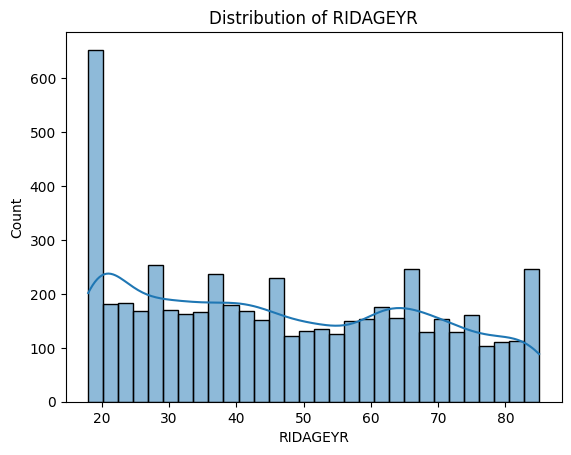

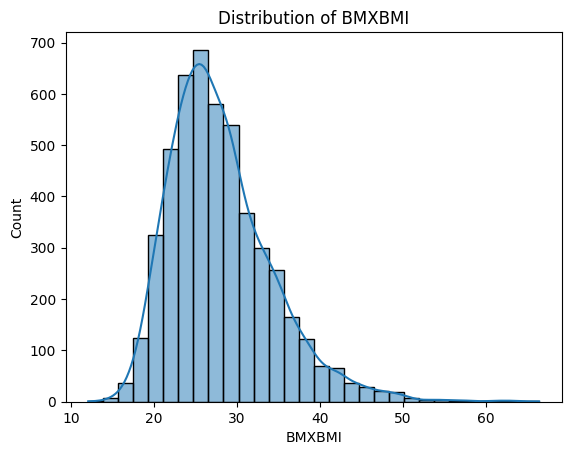

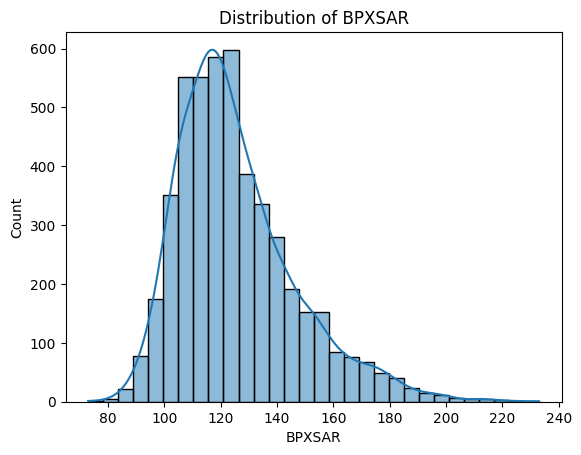

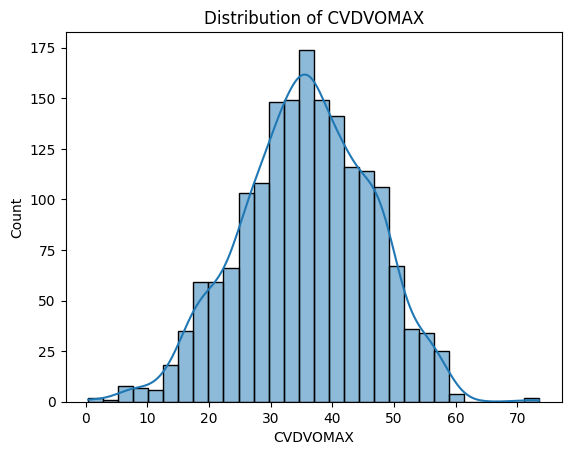

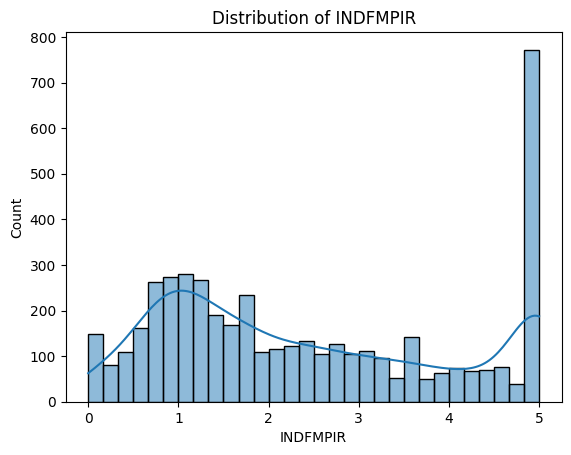

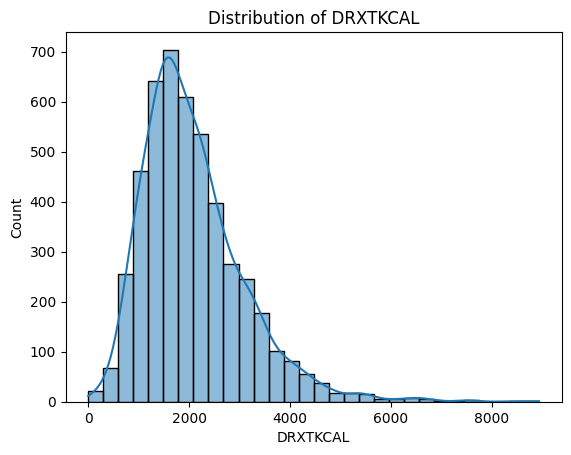

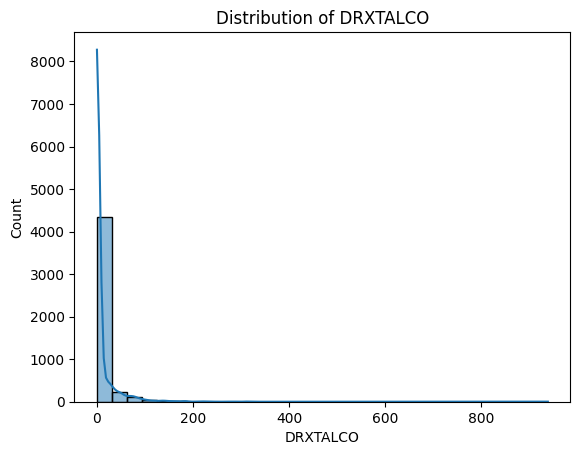

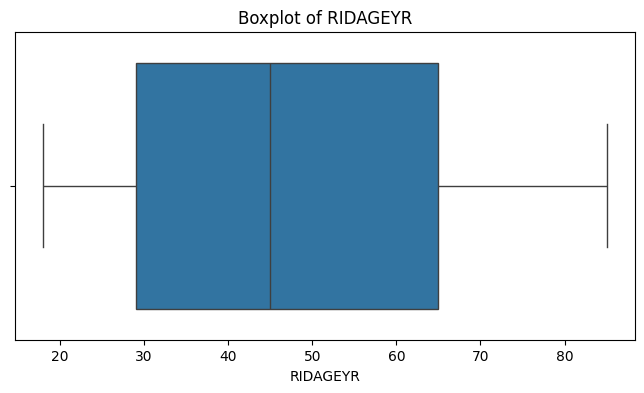

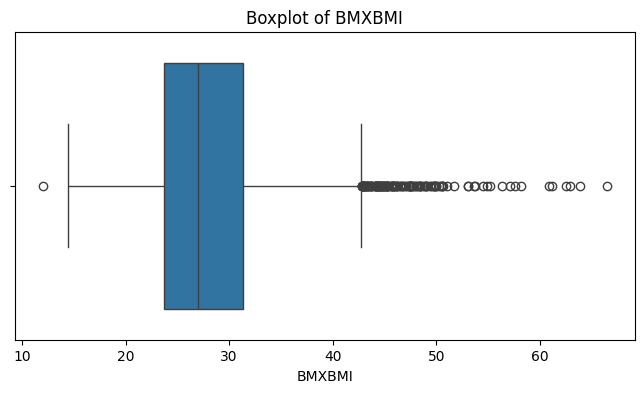

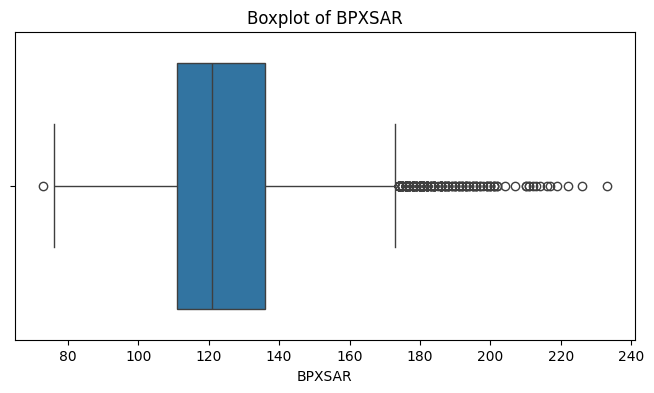

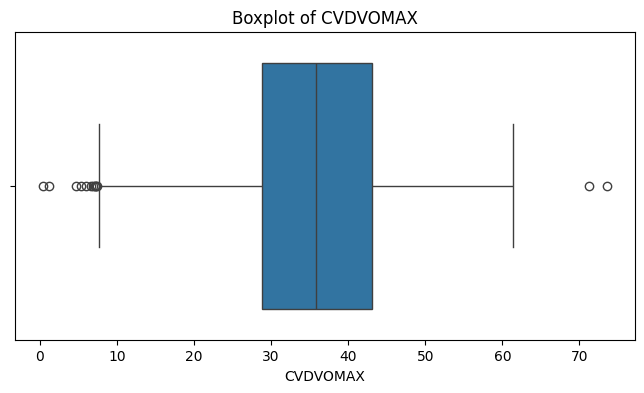

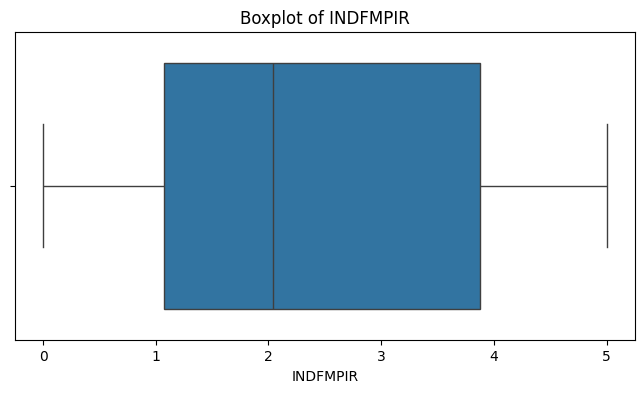

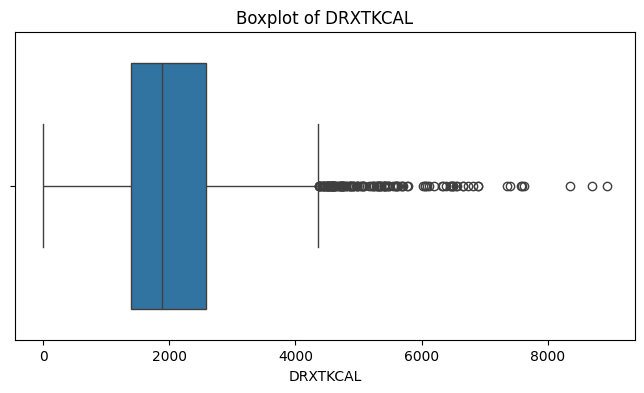

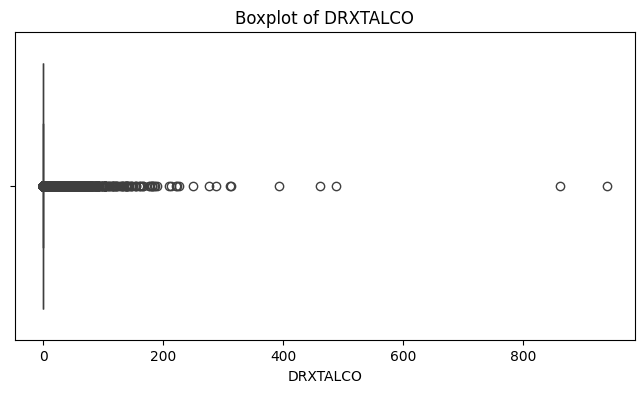

RIDAGEYR: 0 potential outliers
BMXBMI: 133 potential outliers
BPXSAR: 173 potential outliers
CVDVOMAX: 13 potential outliers
INDFMPIR: 0 potential outliers
DRXTKCAL: 134 potential outliers
DRXTALCO: 1088 potential outliers


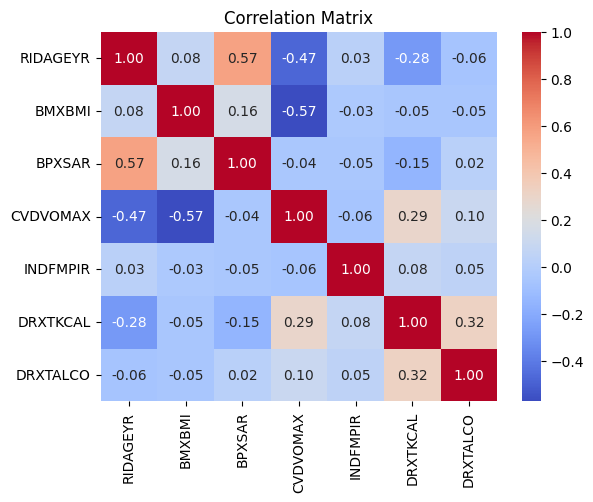

Gender x Race(Counts)
RACE    Mexican American  Non-Hispanic Black  Non-Hispanic White  Other  \
GENDER                                                                    
Female               831                 558                1208    100   
Male                 720                 477                1121     93   
Total               1551                1035                2329    193   

RACE    Other Hispanic  Total  
GENDER                         
Female             200   2897  
Male               137   2548  
Total              337   5445  

Gender x Race (%)
RACE    Mexican American  Non-Hispanic Black  Non-Hispanic White  Other  \
GENDER                                                                    
Female              28.7                19.3                41.7    3.5   
Male                28.3                18.7                44.0    3.6   

RACE    Other Hispanic  
GENDER                  
Female             6.9  
Male               5.4  
Gender x Pulse(Counts)

In [62]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

#Binary mortality outcome
cleaned_merged_df = cleaned_merged_df[cleaned_merged_df['MORTSTAT'].isin([0,1])]
cleaned_merged_df['DIED'] = (cleaned_merged_df['MORTSTAT'] == 1).astype(int)

key_num_vars = [
    'RIDAGEYR',  # Age at screening (years)
    'BMXBMI',    # Body Mass Index
    'BPXSAR',    # Average systolic blood pressure, key hypertension indicator
    'CVDVOMAX',  # Predicted VO2 max, measure of cardiovascular fitness
    'INDFMPIR',  # Income-to-poverty ratio
    'DRXTKCAL',  # Total daily caloric intake
    'DRXTALCO',  # Alcohol consumption
]

#Histograms for each key numerical variable to determine distribution
for var in key_num_vars:
    sns.histplot(cleaned_merged_df[var], kde=True, bins=30)
    plt.title(f'Distribution of {var}')
    plt.show()


#Boxplot to visually check for outliers
for var in key_num_vars:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=cleaned_merged_df[var])
    plt.title(f'Boxplot of {var}')
    plt.show()

#Numerically seeing how many outliers each variable has
for var in key_num_vars:
    Q1 = cleaned_merged_df[var].quantile(0.25)
    Q3 = cleaned_merged_df[var].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = cleaned_merged_df[(cleaned_merged_df[var] < lower_bound) | (cleaned_merged_df[var] > upper_bound)]
    print(f"{var}: {outliers.shape[0]} potential outliers")

#Correlation heatmap to see which numerical variables display the correlation.
corr_matrix = cleaned_merged_df[key_num_vars].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

#Convert gender and race to labels for clarity
cleaned_merged_df['GENDER'] = cleaned_merged_df['RIAGENDR'].map({1.0: 'Male', 2.0: 'Female'})
cleaned_merged_df['RACE'] = cleaned_merged_df['RIDRETH1'].map({
    1.0: 'Mexican American',
    2.0: 'Other Hispanic',
    3.0: 'Non-Hispanic White',
    4.0: 'Non-Hispanic Black',
    5.0: 'Other'
})

#Gender x Race
crosstab_gender_pulse_counts = pd.crosstab(
    cleaned_merged_df['GENDER'],
    cleaned_merged_df['RACE'],
    margins=True,
    margins_name='Total'
)

crosstab_gender_pulse_pct = pd.crosstab(
    cleaned_merged_df['GENDER'],
    cleaned_merged_df['RACE'],
    normalize='index'
).round(3) * 100

print("Gender x Race(Counts)")
print(crosstab_gender_pulse_counts)
print("\nGender x Race (%)")
print(crosstab_gender_pulse_pct)

#Gender x Pulse
crosstab_gender_pulse_counts = pd.crosstab(
    cleaned_merged_df['GENDER'],
    cleaned_merged_df['BPXPULS'],
    margins=True,
    margins_name='Total'
)

crosstab_gender_pulse_pct = pd.crosstab(
    cleaned_merged_df['GENDER'],
    cleaned_merged_df['BPXPULS'],
    normalize='index'
).round(3) * 100

print("Gender x Pulse(Counts)")
print(crosstab_gender_pulse_counts)
print("\nGender x Pulse (%)")
print(crosstab_gender_pulse_pct)

#Race x Pulse
crosstab_race_pulse_counts = pd.crosstab(
    cleaned_merged_df['RACE'],
    cleaned_merged_df['BPXPULS'],
    margins=True,
    margins_name='Total'
)

crosstab_race_pulse_pct = pd.crosstab(
    cleaned_merged_df['RACE'],
    cleaned_merged_df['BPXPULS'],
    normalize='index'
).round(3) * 100

print("\nRace x Pulse (Counts) ")
print(crosstab_race_pulse_counts)
print("\nRace x Pulse (%)")
print(crosstab_race_pulse_pct)


**EDA Discussion**

After merging the datasets, we chose to focus on a few key variables in order to predict mortality rates. These variables are RIDAGEYR (age in years), BMXBMI (Body Mass Index), BPXSAR (average systolic blood pressure), CVDVOMAX (the predicted max VO2), INDFMPIR (income-to-poverty ratio), DRXTKCAL (total daily caloric intake), DRXTALCO (alcohol consumption), BPXPULS (pulse regularity), gender, and race. The variable for age was chosen because age is commonly said to be the biggest predictor of mortality as the risk of death increases with each increase in decade of life. BMI was chosen to account for obesity and a person's weight and height. The variable for systolic blood pressure was chosen as blood pressure is one of the most influential factors in heart health and mortality. The variable for predicted max VO2 was used as a measure of cardiovascular health. The variable for income-to-poverty ratio was chosen to analyze how poverty and wealth can effect health and mortality outcomes. Finally, the variables for alcohol intake and total caloric consumption were chosen to see how a person's dietary choices can effect their mortality. The categorical variables we chose to study were gender, race, and pulse regularity.

After performing exploratory data analysis on these variables, it was found that several variables had a non-uniform and skewed distribution. These variables that have a skewed distribution include income-to-poverty ratio and alcohol intake. Alcohol intake displays a heavy rightward skew while income-to-poverty ratio which displays a heavy leftward skew. The rest of the variables have a somewhat normal distribution with limited skew. For variables like alcohol intake, most people have low alcohol intake however there are a minority that have very high alcohol intake that are causing the skewness. In terms of income to poverty ratio, the skew exists because of the way the data was collected and due to the cap at 5.0.

Furthermore, the variables for BMI, average systolic blood pressure, total calories consumed, and alcohol consumption all have signficicant numbers of outliers at 133, 173, 134, and 1,088 potential outliers respectively. It should be noted that alcohol consumption is quite different from the rest of the variables in the sheer amount of potential outliers there are which could heavily skew the data if not properly accounted for.

When looking at correlation, we can see that certain variables are more correlated than others. The variables for BMI and predicted max VO2 show medium inverse corerelation at -0.57 which is the highest correlation number in the heatmap. This may be because as your BMI increases, your cardiovascular health declines. There was a also mild negative correlation between the variables for age in years and predicted max VO2. This seems to occur because cardiovascular health tends to decrease as you age. As for positive correlations, the variables for age and the average systolic blood pressure showed the most correlation at 0.57 which would represent a moderately strong correlation. This may be because as a person's age increases, their blood pressure may increase and put them at a higher risk for hypertension.  The variables for alcohol consumption and total calories consumed show a weak positive correlation at 0.32. This is probably due to the reason that alcohol has calories in it and as you increase your alcohol intake, you also increase your overall caloric intake. The variables for systolic blood pressure and BMI also show weak positive correlation 0.30 and this might due to link between increased weight and higher blood pressure. The last relationship worth mentioning here is the correlation between predicted max VO2 and total calories consumed at 0.29 which represents a very weak positive correlation. The rest of the variables have too weak of correlations between each other to be significant.

When cross-tabulating the categorical variables of gender and race, we can see that there are almost identical amounts of men and women in the dataset and that there are more Mexican American and Non-Hispanic White observations than Black or other denominations. For the crosstabs between gender and pulse regularity and between race and pulse regularity, we can see that men, non Hispanic black people, and white people are more slightly more likely to have irregular pulses than other categories.




### Part 2: $k$-NN classification/regression, write-up (50/100 pts)

Submit a notebook that clearly addresses the following, using code and markdown chunks:

1. Describe the data, particularly what an observation is and whether there are any missing data that might impact your analysis. Who collected the data and why? What known limitations are there to analysis? (10/100 pts)


2. Describe the variables you selected to predict mortality and life expectancy, and the rationale behind them. Analyze your variables using describe tables, kernel densities, scatter plots, and conditional kernel densities. Are there any patterns of interest to notice? (10/100 pts)


3. Using your variables to predict mortality using a $k$-Nearest Neighbor Classifier. Analyze its performance and explain clearly how you select $k$. (10/100 pts)


4. Using your variables to predict life expectancy using a $k$-Nearest Neighbor Regressor. Analyze its performance and explain clearly how you select $k$. (10/100 pts)

5. Describe how your model could be used for health interventions based on patient characteristics. Are there any limitations or risks to consider? (10/100 pts)


## Submission (10/100 pts)

Submit your work in a well-organized GitHub repo, where the code is appropriately commented and all members of the group have made significant contributions to the commit history. (10/100 pts)